In [1]:
import base64
import json
import requests
import os
from dotenv import load_dotenv
from typing import Dict, Any
from IPython.display import Markdown, display, Image

# Mistral Document AI Basics

Mistral Document AI offers enterprise-level document processing, combining cutting-edge OCR technology with advanced structured data extraction. This notebook showcases a few examples of basic OCR extraction for text and images.

We will be using the `mistral-document-ai-2505` model with a few documents and images to show the capabilities of the model.

> **Note**: The Document AI endpoint on Azure Foundry cannot process sources from external URLSs, instead we show you how to encode documents and images and call the API.

## 0. Setup

From Azure AI Foundry, after clicking on "Use this model" and going through standard Foundry setup you will need the provided Endpoint, Key and Deployment Name.

The Endpoint is used as the url in the REST request, the Key is used for authentication in the header, and the Deployment Name is used in the body of the request.

In [2]:
load_dotenv()

AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT = os.getenv("AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT")
AZURE_MISTRAL_DOCUMENT_AI_KEY = os.getenv("AZURE_MISTRAL_DOCUMENT_AI_KEY")
AZURE_AI_DEPLOYMENT_NAME = os.getenv("AZURE_AI_DEPLOYMENT_NAME")


REQUEST_HEADERS = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {AZURE_MISTRAL_DOCUMENT_AI_KEY}",
}

## 1. Helper Functions

In [3]:
from ocr4_utils import (
    bboxannotation,
    encode_file,
    simple_combined_markdown,
)

import json


def testBBoxAnnotationOutput(response: dict) -> None:
    for page in response.get('pages', []):
        for image in page.get('images', []):
            annotation = json.loads(image['image_annotation'])
            properties = annotation.get('properties', annotation)
            print(f"page {page['index']}")
            print('Image type:', properties.get('image_type'))
            print('Short description:', properties.get('short_description'))

## 2. Image/Document Annotations

In addition to basic OCR functionality, Mistral Document AI has annotations that allow you to extract information from documents and images in structured json with a single call to the API. It offers two types of annotations that can be used independently, or together:

bbox_annotation: gives you the annotation of the bounding boxes extracted by the OCR model (charts/figures etc.) based on a structure that you define in the request. This is provided for every image, in every page of the document.
document_annotation: like the bbox_annotation, but for the extracted text across the entire document.
Note: Document annotations are currently limited at 8 pages. Please see the model card for the most up-to-date information on limits

In [4]:
!wget  -P samples  https://raw.githubusercontent.com/mistralai/cookbook/refs/heads/main/mistral/ocr/receipt.png 
!wget  -P samples https://raw.githubusercontent.com/mistralai/cookbook/refs/heads/main/mistral/ocr/mistral7b.pdf

--2026-08-23 19:25:16--  https://raw.githubusercontent.com/mistralai/cookbook/refs/heads/main/mistral/ocr/receipt.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3110191 (3.0M) [image/png]
Saving to: ‘samples/receipt.png.4’

receipt.png.4       100%[===================>]   2.97M  8.43MB/s    in 0.4s    

2026-08-23 19:25:17 (8.43 MB/s) - ‘samples/receipt.png.4’ saved [3110191/3110191]

--2026-08-23 19:25:18--  https://raw.githubusercontent.com/mistralai/cookbook/refs/heads/main/mistral/ocr/mistral7b.pdf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting re

Construct the request and parse the response

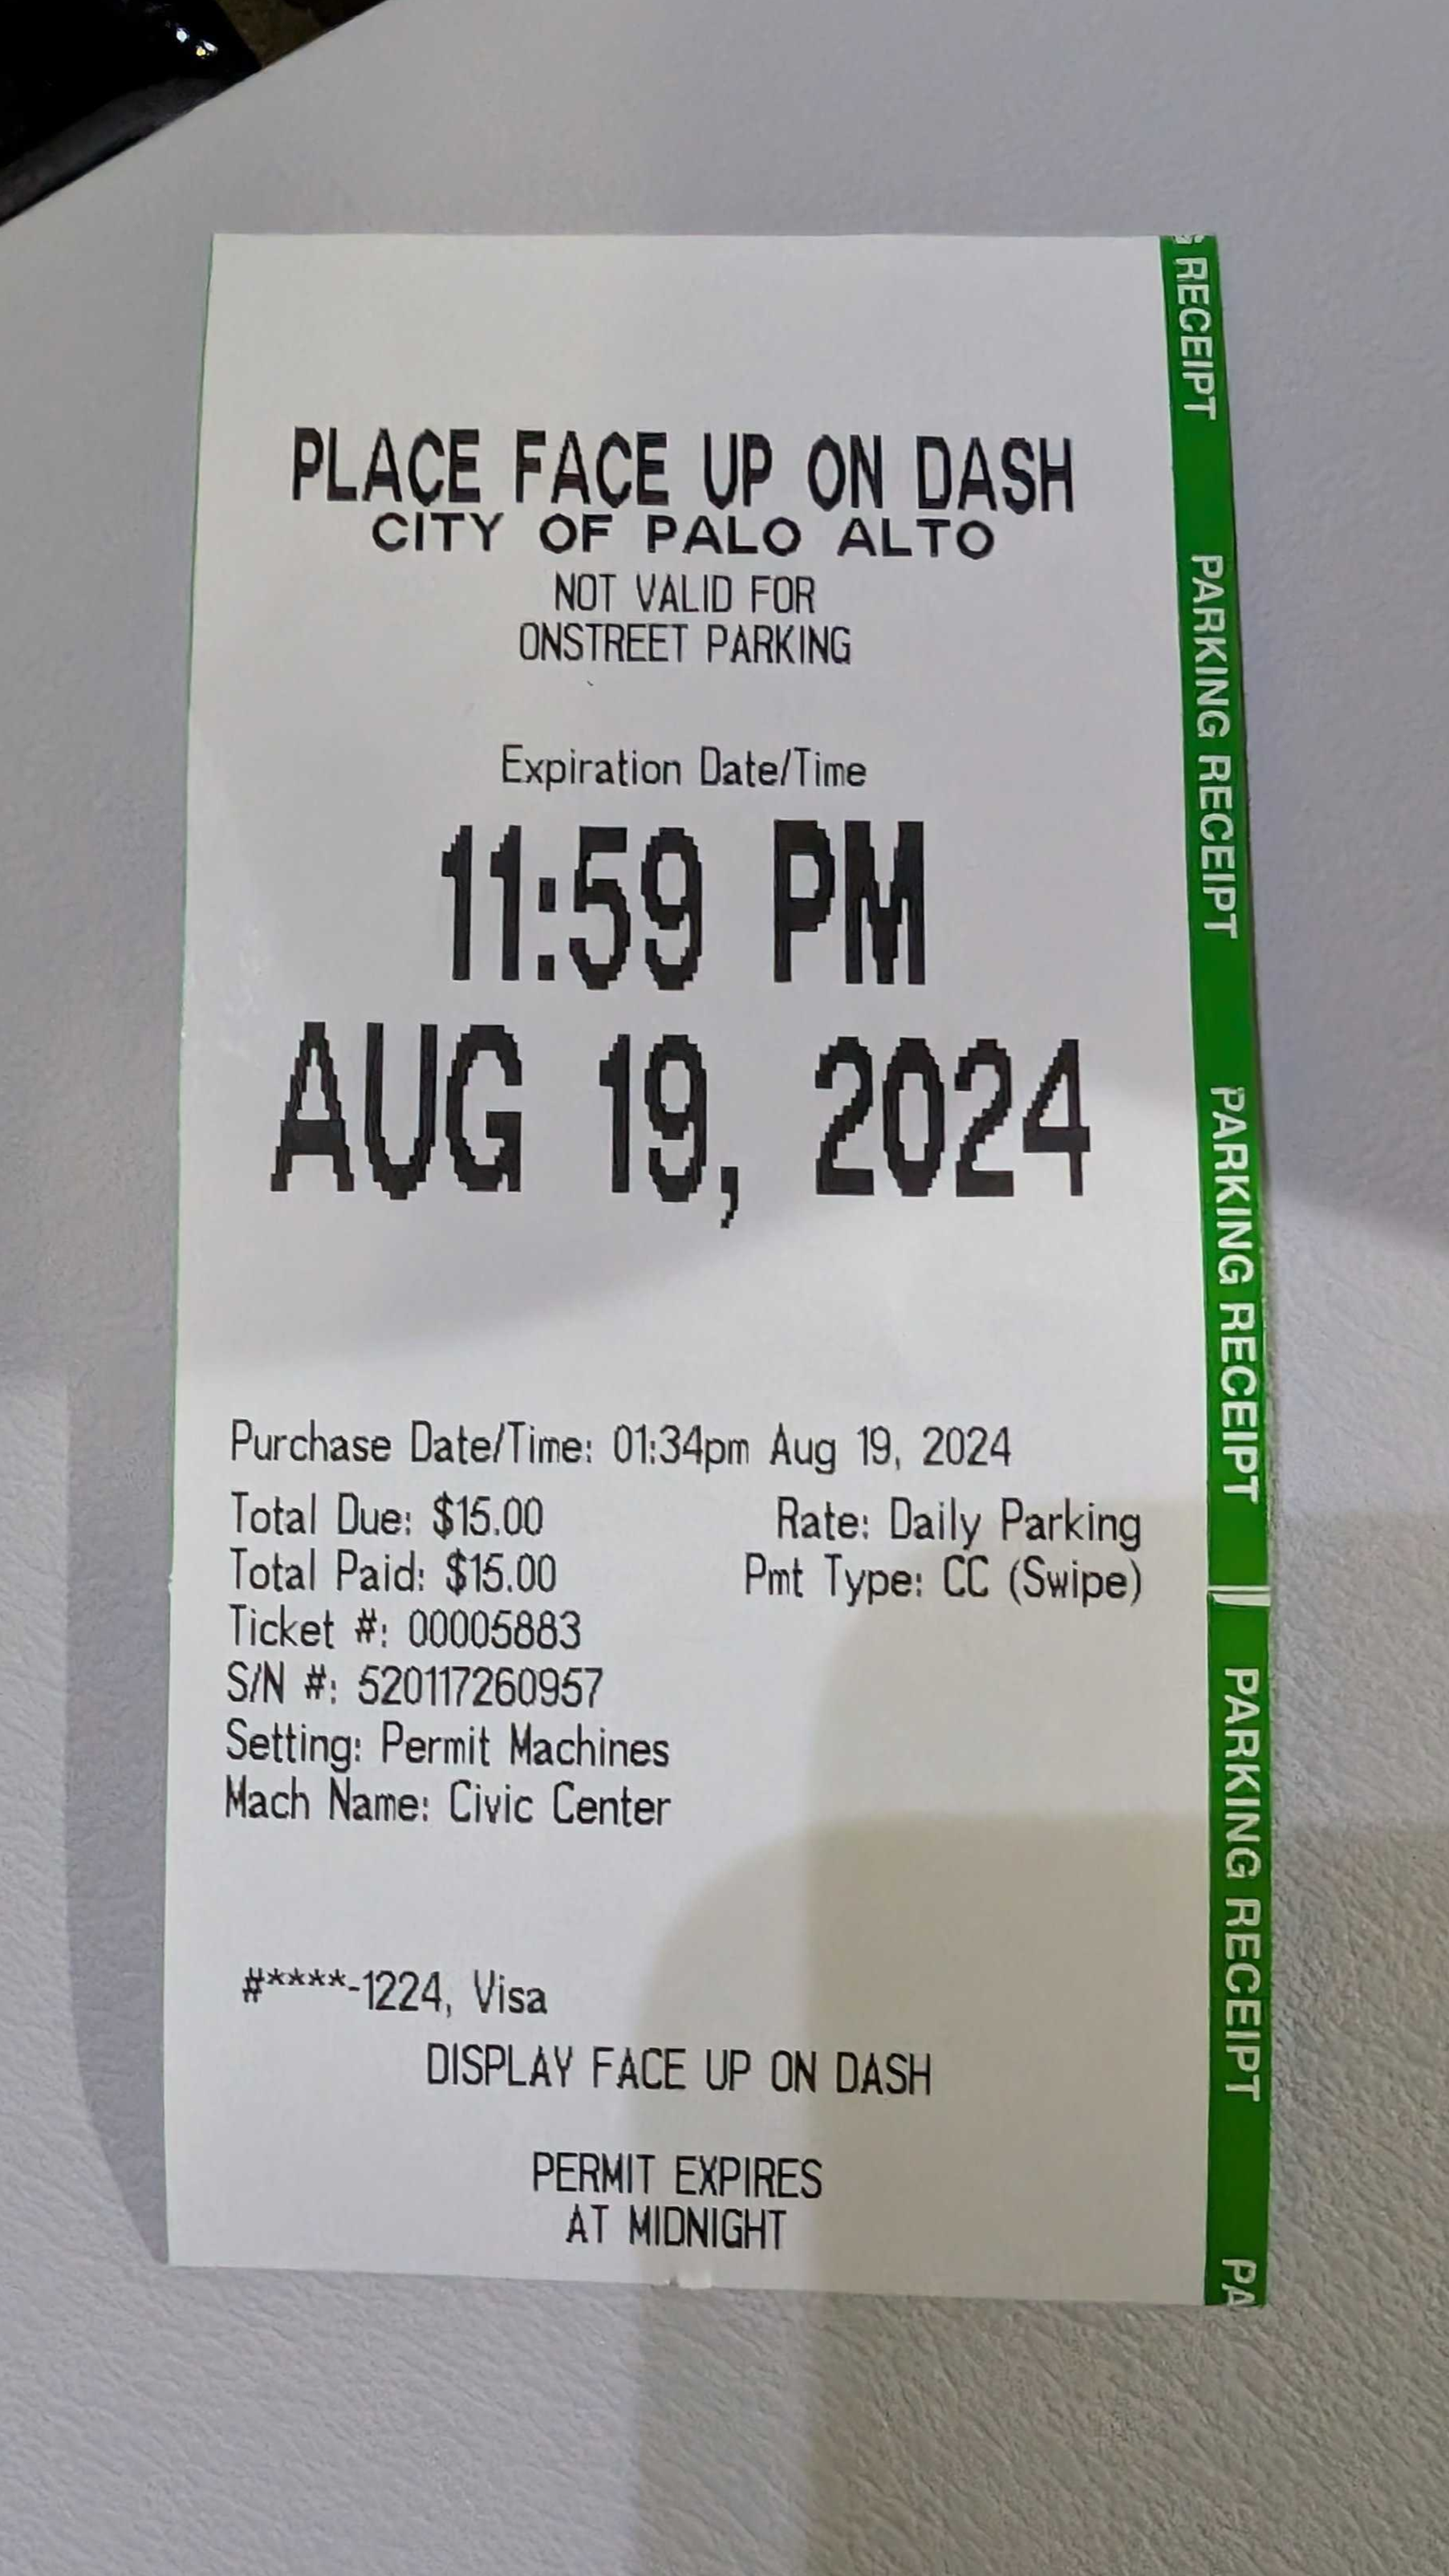

In [5]:
display(Image(filename="samples/receipt.png"))

In [6]:
bb1Response_image = requests.post(
    url=AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT,
    json=bboxannotation(encode_file("samples/receipt.png"), 'document_annotation_format'),
    headers=REQUEST_HEADERS,
)

In [9]:
response = bb1Response_image.json()
doc_annotation = json.loads(response["document_annotation"])
doc_annotation["short_description"]


'Parking receipt for Civic Center, Palo Alto. Daily parking rate, paid with credit card. Expires at midnight on Aug 19, 2024. Ticket #00005883, S/N #520117260957.'

In [10]:
bb1Response_image.json()

{'pages': [{'index': 0,
   'markdown': '# PLACE FACE UP ON DASH\nCITY OF PALO ALTO\n\nNOT VALID FOR\nONSTREET PARKING\n\nExpiration Date/Time\n\n# 11:59 PM\nAUG 19, 2024\n\nPurchase Date/Time: 01:34pm Aug 19, 2024\n\nTotal Due: $15.00\n\nTotal Paid: $15.00\n\nTicket #: 00005883\n\nS/N #: 520117260957\n\nSetting: Permit Machines\n\nMach Name: Civic Center\n\nRate: Daily Parking\n\nPmt Type: CC (Swipe)\n\n#***-1224, Visa\n\nDISPLAY FACE UP ON DASH\n\nPERMIT EXPIRES\n\nAT MIDNIGHT\n\nRECEIPT\n\nPARKING RECEIPT\n\nPARKING RECEIPT\n\nPARKING RECEIPT\n\nPA',
   'images': [],
   'tables': [],
   'hyperlinks': [],
   'header': None,
   'footer': None,
   'dimensions': {'dpi': 200, 'height': 3210, 'width': 1806},
   'confidence_scores': {'word_confidence_scores': [],
    'average_page_confidence_score': 0.9637913327648899,
    'minimum_page_confidence_score': 0.18416026580246883},
   'blocks': [{'top_left_x': 356,
     'top_left_y': 521,
     'bottom_right_x': 1341,
     'bottom_right_y': 700,


Retrieve Confidence Score

In [11]:
print(response["pages"][0]["confidence_scores"])

{'word_confidence_scores': [], 'average_page_confidence_score': 0.9637913327648899, 'minimum_page_confidence_score': 0.18416026580246883}


Retreive Blocks based on 'include_blocks' set to True

In [12]:
print(response["pages"][0]["blocks"][0])

{'top_left_x': 356, 'top_left_y': 521, 'bottom_right_x': 1341, 'bottom_right_y': 700, 'content': '# PLACE FACE UP ON DASH\nCITY OF PALO ALTO', 'type': 'title'}


In [14]:
bb1Response_document = requests.post(
    url=AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT,
    json=bboxannotation(encode_file("samples/mistral7b.pdf"), 'bbox_annotation_format'),
    headers=REQUEST_HEADERS,
)

In [16]:
image = bb1Response_document.json()["pages"][0]["images"][0]
iaj = json.loads(image["image_annotation"])
print(iaj["short_description"])

A 3D rendering of the text 'Mistral AI' in orange and brown colors.


You will notice that for every page, the API returns text data in html format, along with information about detected images.

# 3. Header/Footer Extraction Example

In [18]:
display(Markdown(bb1Response_document.json()["pages"][6]["header"]))

Llama 2 13b
1 Health Remaining
Mistral 7b
5 Health Remaining

In [19]:
display(bb1Response_document.json()["pages"][4]["footer"])


'5'

# 4. Tabular Example

Next we look at a document with tabular data, for this example we are using Microsoft's 8-K filing located here: https://www.microsoft.com/en-us/investor/sec-filings 

In [20]:
ms8kDocument = encode_file("samples/0000950170-25-100226.pdf")

In [21]:
msRequestPayload = {
    "model": f"{AZURE_AI_DEPLOYMENT_NAME}",
    "document": {
        "type": "document_url",
        "document_url": f"data:application/pdf;base64,{ms8kDocument}",
    },
    "table_format": "html",
    "extract_header": True, 
    "extract_footer": True,
}

In [22]:
ms8kResponse = requests.post(
    url=AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT,
    json=msRequestPayload,
    headers=REQUEST_HEADERS,
)

Selecting a page with tables

In [23]:
display(ms8kResponse.json()["pages"][0]["header"])

None

In [24]:
print(ms8kResponse.json()["pages"][0]["tables"][0]['content'])

<table><thead><tr><th>Title of each class</th><th>Trading<br/>Symbol</th><th>Name of exchange on which registered</th></tr></thead><tr><td><b>Common stock, $0.00000625 par value per share</b></td><td><b>MSFT</b></td><td><b>NASDAQ</b></td></tr><tr><td><b>3.125% Notes due 2028</b></td><td><b>MSFT</b></td><td><b>NASDAQ</b></td></tr><tr><td><b>2.625% Notes due 2033</b></td><td><b>MSFT</b></td><td><b>NASDAQ</b></td></tr></table>


In [25]:
print(ms8kResponse.json()["pages"][0]["markdown"])

# **UNITED STATES**
**SECURITIES AND EXCHANGE COMMISSION**
**WASHINGTON, D.C. 20549**

# **FORM 8-K**

# **CURRENT REPORT**
**PURSUANT TO SECTION 13 OR 15(D)**
**OF THE SECURITIES EXCHANGE ACT OF 1934**

**Date of Report (Date of earliest event reported) July 30, 2025**

# **Microsoft Corporation**

**Washington**
(State or Other Jurisdiction
of Incorporation)

**001-37845**
(Commission
File Number)

**91-1144442**
(IRS Employer
Identification No.)

**One Microsoft Way, Redmond, Washington 98052-6399**

**(425) 882-8080**
www.microsoft.com/investor

Check the appropriate box below if the Form 8-K filing is intended to simultaneously satisfy the filing obligation of the registrant under any of the following provisions (see General Instruction A.2. below):

☐ Written communications pursuant to Rule 425 under the Securities Act (17 CFR 230.425)
☐ Soliciting material pursuant to Rule 14a-12 under the Exchange Act (17 CFR 240.14a-12)
☐ Pre-commencement communications pursuant to Rule 14d-2(

In [26]:
display(Markdown(simple_combined_markdown(ms8kResponse.json()["pages"][0])))

# **UNITED STATES**
**SECURITIES AND EXCHANGE COMMISSION**
**WASHINGTON, D.C. 20549**

# **FORM 8-K**

# **CURRENT REPORT**
**PURSUANT TO SECTION 13 OR 15(D)**
**OF THE SECURITIES EXCHANGE ACT OF 1934**

**Date of Report (Date of earliest event reported) July 30, 2025**

# **Microsoft Corporation**

**Washington**
(State or Other Jurisdiction
of Incorporation)

**001-37845**
(Commission
File Number)

**91-1144442**
(IRS Employer
Identification No.)

**One Microsoft Way, Redmond, Washington 98052-6399**

**(425) 882-8080**
www.microsoft.com/investor

Check the appropriate box below if the Form 8-K filing is intended to simultaneously satisfy the filing obligation of the registrant under any of the following provisions (see General Instruction A.2. below):

☐ Written communications pursuant to Rule 425 under the Securities Act (17 CFR 230.425)
☐ Soliciting material pursuant to Rule 14a-12 under the Exchange Act (17 CFR 240.14a-12)
☐ Pre-commencement communications pursuant to Rule 14d-2(b) under the Exchange Act (17 CFR 240.14d-2(b))
☐ Pre-commencement communications pursuant to Rule 13e-4(c) under the Exchange Act (17 CFR 240.13e-4(c))

Securities registered pursuant to Section 12(b) of the Act:

[tbl-0.html](tbl-0.html)

Indicate by check mark whether the registrant is an emerging growth company as defined in Rule 405 of the Securities Act of 1933 (§230.405 of this chapter) or Rule 12b-2 of the Securities Exchange Act of 1934 (§240.12b-2 of this chapter). Emerging growth company ☐

If an emerging growth company, indicate by check mark if the registrant has elected not to use the extended transition period for complying with any new or revised financial accounting standards provided pursuant to Section 13(a) of the Exchange Act. ☐

As observed, the extracted text in the table is accurate and true to the original tabular representation.

# 5. Microsoft Word Documents

In [27]:
wordDocument = encode_file("samples/TranscriptFY25q4.docx")

In [28]:
wordPayload = {
    "model": f"{AZURE_AI_DEPLOYMENT_NAME}",
    "document": {
        "type": "document_url",
        "document_url": f"data:application/vnd.openxmlformats-officedocument.wordprocessingml.document;base64,{wordDocument}",
    },
    "table_format": "html",
    "extract_header": True, 
    "extract_footer": True, 
}

In [29]:
wordResponse = requests.post(
    url=AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT,
    json=wordPayload,
    headers=REQUEST_HEADERS,
)

In [30]:
print(wordResponse.json()["pages"][0]['markdown'])

**Microsoft Cloud and AI Strength Fuels Fourth Quarter Results**

**REDMOND, Wash. — July 30, 2025 —** Microsoft Corp. today announced the following results for the quarter ended June 30, 2025, as compared to the corresponding period of last fiscal year:

- Revenue was $76.4 billion and increased 18% (up 17% in constant currency)
- Operating income was $34.3 billion and increased 23% (up 22% in constant currency)
- Net income was $27.2 billion and increased 24% (up 22% in constant currency)
- Diluted earnings per share was $3.65 and increased 24% (up 22% in constant currency)

“Cloud and AI is the driving force of business transformation across every industry and sector," said Satya Nadella, chairman and chief executive officer of Microsoft. “We’re innovating across the tech stack to help customers adapt and grow in this new era, and this year, Azure surpassed $75 billion in revenue, up 34 percent, driven by growth across all workloads.”

“We closed out the fiscal year with a strong qu

In [31]:
# limiting to 1000 characters for easier reading
display(Markdown(simple_combined_markdown(wordResponse.json()["pages"][0])[:1000]))

**Microsoft Cloud and AI Strength Fuels Fourth Quarter Results**

**REDMOND, Wash. — July 30, 2025 —** Microsoft Corp. today announced the following results for the quarter ended June 30, 2025, as compared to the corresponding period of last fiscal year:

- Revenue was $76.4 billion and increased 18% (up 17% in constant currency)
- Operating income was $34.3 billion and increased 23% (up 22% in constant currency)
- Net income was $27.2 billion and increased 24% (up 22% in constant currency)
- Diluted earnings per share was $3.65 and increased 24% (up 22% in constant currency)

“Cloud and AI is the driving force of business transformation across every industry and sector," said Satya Nadella, chairman and chief executive officer of Microsoft. “We’re innovating across the tech stack to help customers adapt and grow in this new era, and this year, Azure surpassed $75 billion in revenue, up 34 percent, driven by growth across all workloads.”

“We closed out the fiscal year with a strong qu

# 6. Microsoft Powerpoint Presentations

In [32]:
!wget -P samples https://github.com/mistralai/cookbook/raw/52ed72962a4d2be2c922919d7c25016b71b900df/data/sample.pptx

--2026-08-23 19:30:51--  https://github.com/mistralai/cookbook/raw/52ed72962a4d2be2c922919d7c25016b71b900df/data/sample.pptx
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mistralai/cookbook/52ed72962a4d2be2c922919d7c25016b71b900df/data/sample.pptx [following]
--2026-08-23 19:30:52--  https://raw.githubusercontent.com/mistralai/cookbook/52ed72962a4d2be2c922919d7c25016b71b900df/data/sample.pptx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7002042 (6.7M) [application/octet-stream]
Saving to: ‘samples/sample.pptx.2’

sample.pptx.2       100%[===================>]   6.68M  1.95MB/s    in 3.4s   

In [33]:
powerpointDocument = encode_file("samples/sample.pptx")

In [34]:
pptxPayload = {
    "model": f"{AZURE_AI_DEPLOYMENT_NAME}",
    "document": {
        "type": "document_url",
        "document_url": f"data:application/vnd.openxmlformats-officedocument.presentationml.presentation;base64,{powerpointDocument}",
    },
    "include_image_base64": "false",
    "image_limit": 0,
    "table_format": "html",
    "extract_header": True, 
    "extract_footer": True, 
}

In [35]:
pptxResponse = requests.post(
    url=AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT,
    json=pptxPayload,
    headers=REQUEST_HEADERS,
)

In [36]:
pptxResponse.json()["pages"][0]['markdown']

'# Frontier AI. \x0bIn your hands.\nConfigurable AI for all builders\n\n# July 2025\n\nConfidential ©2025 Mistral AI\\. All rights reserved\\.'

In [37]:
print(json.dumps(pptxResponse.json(), indent=4))

{
    "pages": [
        {
            "index": 0,
            "markdown": "# Frontier AI. \u000bIn your hands.\nConfigurable AI for all builders\n\n# July 2025\n\nConfidential \u00a92025 Mistral AI\\. All rights reserved\\.",
            "images": [],
            "tables": [],
            "hyperlinks": [],
            "header": null,
            "footer": null,
            "dimensions": null,
            "confidence_scores": null,
            "blocks": null
        },
        {
            "index": 1,
            "markdown": "# The Mistral AI model landscape\n\n__Our __  __moderation service__  __ to detect __  __harmful__  __ text content__\n\n__Our __  __most __  __efficient / powerful__  __edge__  __ models__\n\n__Our __  __frontier\\-class reasoning __  __model__\n\n__Our flagship model\\, for__  __your __  __most sophisticated needs__\n\n__Mistral Moderation__\n\n__Mistral Medium 3__\n\n__Magistral Medium __\n\n__The world\u2019s __  __best OCR model __  __to\\-date__\n\n__Our __

EPub File Format

In [38]:
epubDocument = encode_file("samples/minimal.epub")

In [39]:
epubPayload = {
    "model": f"{AZURE_AI_DEPLOYMENT_NAME}",
    "document": {
        "type": "document_url",
        "document_url": f"data:application/epub+zip;base64,{epubDocument}",
    },
    "include_image_base64": "false",
    "image_limit": 0,
    "table_format": "html",
    "extract_header": True, 
    "extract_footer": True, 
}

In [40]:
epubResponse = requests.post(
    url=AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT,
    json=epubPayload,
    headers=REQUEST_HEADERS,
)

In [41]:
epubResponse.json()["pages"][0]['markdown']

'# Chapter 1\n\nLorem ipsum dolor sit amet, consectetur adipiscing elit. Morbi id lectus dictum, lobortis urna a, luctus libero. Integer ultricies nisi nec nisi gravida, sit amet tempor diam posuere. Morbi consequat libero fringilla pellentesque venenatis. Donec ut porta metus. Etiam condimentum cursus elit pulvinar gravida. Nulla consequat interdum leo sed tincidunt. Suspendisse potenti. Integer pretium cursus libero, eu ornare erat dictum eu. Cras ultrices mi vel odio tempus fringilla. Nulla tristique nisi nisl, id scelerisque risus gravida a. Proin neque tellus, efficitur eu dictum hendrerit, lacinia vel neque. Proin augue risus, maximus ac eros consectetur, finibus mattis metus. Donec ut dictum diam. Vestibulum tempor orci id ultrices lacinia. Praesent bibendum, mi vitae euismod condimentum, eros enim tincidunt odio, id semper erat nisl vitae nisi. Nunc convallis mi sit amet velit venenatis vestibulum ac at mauris.\n\nDuis vestibulum elit non tortor luctus ultrices. Nulla facilisi.

# 7. Wrap-up

Documents and images are a wealth of information, but that information is only useful if it can be extracted accurately. Mistral Document AI on Azure is a powerful tool that can help you extract text and images from documents accurately, with ease. We hope you found this notebook helpful and we look forward to seeing what you build with it!